### 1.마스크이미지를 활용해서 원하는 이미지 가져오기
 - 마스크 : 특정 픽셀을 살리고 나머지는 가리기 위한 흑백 이미지

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# OpenCV 이미지 여러 개를 Matplotlib을 이용해 한번에 출력하는 함수
def im_show(*opencv_images):
    img_number = len(opencv_images)
    plt.figure(figsize=(4*img_number,4))
    for idx, img in enumerate(opencv_images):
        plt.subplot(1, img_number, idx+1)

        # 그레이스케일 이미지 처리
        if len(img.shape) == 2:
            # 그레이스케일 이미지
            plt.imshow(img, cmap='gray')
        else:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
        # plt.axis('off')  # 축 표시 제거
    plt.show()

In [3]:
# 원본 이미지 로드
original_img = cv2.imread('data/example_img1.png')

# 마스크 이미지 로드 (원본 이미지와 같은 크기, 흑백 이미지)
# 마스크 이미지는 1채널 그레이스케일로 읽음. 흰색(255)에 가까운 영역은 살리고, 검은색(0)에 가까운 영역은 제거
mask = cv2.imread('data/mask_heart.jpg', cv2.IMREAD_GRAYSCALE)
# bitwise_not : 흑백 반전
# 원본 마스크와 반대 영역을 선택하고 싶을 때 사용
mask2 = cv2.bitwise_not(mask)


(640, 1024, 3)


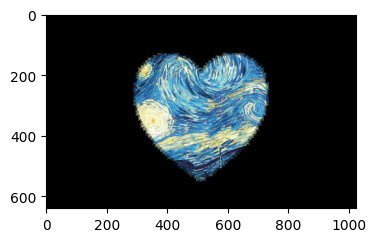

In [4]:
# 마스크 이미지를 이용해서 특정 부분만 보존
# 추가 이미지
image2 = cv2.imread('data/kakao_13.jpg')
image2 = cv2.resize(image2, (1024, 640), interpolation=cv2.INTER_AREA)
print(image2.shape)

# mask가 흰색인 영역만 original_img 남김
masked_img = cv2.bitwise_and(original_img, original_img, mask=mask)
masked_img2 = cv2.bitwise_and(image2, image2, mask=mask2)

# # 최종 결과 이미지 표시
cv2.imwrite("masked_img.jpg", masked_img)
cv2.imshow('masked_img', masked_img)
cv2.imshow('masked_img2', masked_img2)
cv2.waitKey(0)
cv2.destroyAllWindows()

# matplotlib 로 출력하기
im_show(masked_img)

### 1-2.마스크 이미지 적용 -> 알파채널을 이용해서 마스크 제작
- PNG처럼 투명도를 이미지는 보통 B, G, R, Alpha 네 채널로 저장.
- Alpha 채널은 픽셀의 불투명도를 나타내므로 자연스러운 마스크로 사용 가능

In [5]:
# 원본 이미지 로드
original_img = cv2.imread('data/example_img1.png')
print(original_img.shape)



(640, 1024, 3)


In [6]:
# 알파 채널 이미지 로드
# IMREAD_UNCHANGED를 사용하면 PNG의 알파 채널까지 그대로 읽음
mask = cv2.imread('data/cat_face.png', cv2.IMREAD_UNCHANGED)
print(mask.shape)

(500, 500, 4)


In [7]:
# split으로 4개 채널을 분리, 이 중 알파 채널만 마스크로 사용.
_, _, _, alpha_channel = cv2.split(mask)

In [8]:
h, w = original_img.shape[:2]
resized_mask = cv2.resize(alpha_channel, (w, h), interpolation=cv2.INTER_AREA)
resized_mask.shape

(640, 1024)

In [9]:
# 알파 채널에서 불투명한 영역만 원본 이미지에 남김
masked_img = cv2.bitwise_and(original_img, original_img, mask=resized_mask)

cv2.imshow("masked_img", masked_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [10]:
# 원본 이미지 중앙 근처의 500 x 500 영역을 잘라님
# 슬라이싱 img[y1:y2, x1,x2] 순서
target_img = original_img[320-250:320+250, 512-250:512+250]

cv2.imshow("target_img", target_img)
cv2.imshow("original_img", original_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [11]:
target_img.shape

(500, 500, 3)

In [12]:
mask.shape

(500, 500, 4)

In [13]:
# 대상 이미지(target_img)와 같은 크기로 알파 채널을 조정하여 적용해야 함
alpha_channel_resized = cv2.resize(alpha_channel, (target_img.shape[1], target_img.shape[0]), interpolation=cv2.INTER_AREA)

In [15]:
# 크기를 맞춘 알파 채널을 마스크로 사용해 target_img의 원하는 부분만 남김.
masked_img_target = cv2.bitwise_and(target_img, target_img, mask=alpha_channel_resized)

cv2.imshow("masked_img_target", masked_img_target)
cv2.waitKey(0)
cv2.destroyAllWindows()

### 2.특징점 검출

- 특징점(Feature Points)은 이미지에서 중요한 정보가 포함된 지점을 의미
- 이러한 특징점은 이미지 매칭, 객체 인식, SLAM(Simultaneous Localization and Mapping), 3D 재구성 등의 컴퓨터 비전 및 영상 처리 분야에서 핵심적으로 사용됨


- 특징점의 대표적인 유형
    - 코너(Corner, 모서리) → Harris Corner Detection
    - 에지(Edge, 경계선) → Sobel, Canny Edge Detection
    - 블롭(Blob, 국소적 극대/극소 영역) → SIFT, SURF
    - 키포인트(Keypoint) + 기술자(Descriptor) → SIFT, ORB

In [16]:
# 이미지 읽기
img = cv2.imread('data/example_img1.png')

# 대부분의 특징점 검출 알고리즘은 밝기 변화가 핵심. 그레이스케일 사용.
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [17]:
# Harris Corner Detection : 주변 방향으로 밝기 변화가 모두 큰 지점을 코너로 판단.
gray = np.float32(gray)
dst = cv2.cornerHarris(gray,            
                       blockSize=2,     # 코너 판단에 사용할 주변 영역 크기
                       ksize=3,         # Sobel 미분 커널 크기
                       k=0.04)          # K : 해리스 감도 계수(0.04~0.06)

# 검출된 코너 영역을 조금 확장해서 화면에 더 잘 보이게
dst = cv2.dilate(dst, None)

# 임계값을 초과하는 코너에 색상 표시
img[dst > 0.01 * dst.max()] = [0, 0, 255]  # 검출된 코너를 빨간색으로 표시

# 결과 출력
cv2.imshow('Harris Corners', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

- SIFT (Scale-Invariant Feature Transform)
    - 이미지에서 특징점(특징이 뚜렷한 지점) 을 검출하고, 크기와 회전에 영향을 받지 않도록 표현하는 알고리즘
    - 물체 인식, 이미지 정합(Image Matching), SLAM 등에 사용됨

In [18]:
# 이미지 읽기
img = cv2.imread('data/example_img1.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# SIFT 생성
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

# 키포인트를 이미지에 그리기
img_sift = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

cv2.imshow('SIFT Keypoints', img_sift)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
# 동그라미 하나 = SIFT가 찾은 특징점 1개
# 동그라미 중심 = 특징점의 위치
# 동그라미 크기 = 그 특징점이 감지된 스케일
# 동그라미 안의 선 = 그 특징점의 대표 방향

### 3.특징 매칭

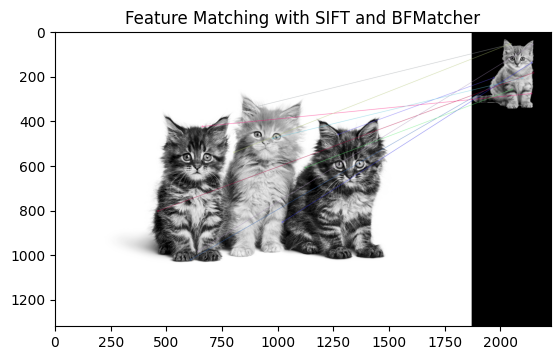

In [19]:
# 이미지 파일 경로 설정
image_path1 = 'data/cat1.png'
image_path2 = 'data/cat_test.png'

# 이미지 읽기
img1 = cv2.imread(image_path1, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(image_path2, cv2.IMREAD_GRAYSCALE)
if img1 is None or img2 is None:
    raise ValueError("Error: Could not open or find the images")

# SIFT 특징점 검출
# keypoints : 특징점 위치
# descriptors : 그 특징점 주변이 어떻게 생겼는지를 숫자로 표현한 값
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Brute-Force 매칭기 생성 및 매칭
# crossCheck=True 서로가 서로의 최선 매칭일 때만 결과로 인정
# 첫번째 이미지의 특징점 하나를 두 번째 이미지의 모든 특징점과 비교해서 가장 비슷한 것을 찾음.
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key=lambda x: x.distance)

# 매칭 결과 이미지 그리기
# 가장 좋은 10개 선만 그려라
img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(img_matches)
plt.title('Feature Matching with SIFT and BFMatcher')
plt.show()